In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)
import pandas as pd
import torch
import os
import shutil
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from PIL import Image
from collections import Counter
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
import timm
import torch.nn.functional as F
import random
from tqdm.auto import tqdm
import copy

# InsightFace — model_zoo classes
from insightface.model_zoo.scrfd import SCRFD
from insightface.model_zoo.arcface_onnx import ArcFaceONNX
from insightface.utils import face_align as insightface_face_align

print('Imports OK')

Imports OK


In [3]:
# ──────────────────────────────────────────────
# Configuración global — sin hardcodeo de paths
# ──────────────────────────────────────────────
MODEL_DIR      = Path('models')
DET_MODEL_PATH = MODEL_DIR / 'det_10g.onnx'
REC_MODEL_PATH = MODEL_DIR / 'w600k_r50.onnx'

SEED = 42
# Python
random.seed(SEED)
# NumPy
np.random.seed(SEED)
# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

FACE_SIZE       = 112          # tamaño esperado por ArcFace
EMBED_DIM       = 512          # dimensión del embedding
N_CLASSES       = 8            # clases a analizar (balance costo/claridad visual)
MIN_FACES_LFW   = 30           # mínimo de imágenes por persona en LFW
TEST_SIZE       = 0.25         # fracción de test
RANDOM_STATE    = 42
COSINE_THRESHOLD = 0.55        # umbral de identificación (calibrado en Sección 6)

# Verificar que los modelos estén disponibles
for p in [DET_MODEL_PATH, REC_MODEL_PATH]:
    status = '✓' if p.exists() else '✗ NO ENCONTRADO'
    print(f'  {status}  {p}')

  ✓  models/det_10g.onnx
  ✓  models/w600k_r50.onnx


In [4]:
# Cargar CSV
df = pd.read_csv("face_dataset_raw/Labels.csv")

train_df=df[df["split"] == "train"]
val_df=df[df["split"] == "val"]
test_df=df[df["split"] == "test"]

In [5]:
print("Imagenes en conjunto de TRAIN:" , len(train_df))
train_df.head()

Imagenes en conjunto de TRAIN: 79


,path,label,name,split,source
0,face_dataset_raw/train/Alfredo_Sanz/Alfredo_Sa...,0,Alfredo Sanz,train,propio
1,face_dataset_raw/train/Alfredo_Sanz/Alfredo_Sa...,0,Alfredo Sanz,train,propio
2,face_dataset_raw/train/Alfredo_Sanz/Alfredo_Sa...,0,Alfredo Sanz,train,propio
5,face_dataset_raw/train/Alma_Lopez/Alma_Lopez_0...,1,Alma Lopez,train,propio
6,face_dataset_raw/train/Alma_Lopez/Alma_Lopez_0...,1,Alma Lopez,train,propio


Como podemos observar, el conjunto de entrenamiento cuenta únicamente con 79 imágenes distribuidas en 20 clases diferentes, lo que representa un promedio aproximado de 4 imágenes por clase. Esta cantidad resulta muy reducida para entrenar un modelo de reconocimiento facial, especialmente considerando la gran cantidad de parámetros que posee la arquitectura seleccionada.

En este contexto, el modelo puede memorizar fácilmente las características específicas de las imágenes de entrenamiento, generando un problema de sobreajuste (overfitting). Esto implica que el sistema aprende correctamente las imágenes conocidas, pero presenta dificultades para generalizar frente a nuevas fotografías no vistas durante el entrenamiento.

Por este motivo, resulta necesario aplicar técnicas de aumento de datos (data augmentation), con el objetivo de incrementar la variabilidad del conjunto de entrenamiento sin alterar el equilibrio entre las clases.

In [7]:
# Carga de modelos ONNX
print('Cargando modelo de detección (SCRFD-10G-BNKPS)...')
det_model = SCRFD(model_file=str(DET_MODEL_PATH))
det_model.prepare(ctx_id=-1, input_size=(1024, 1024))  # ctx_id=-1 → CPU

print('Cargando modelo de reconocimiento (ArcFace W600K-R50)...')
rec_model = ArcFaceONNX(model_file=str(REC_MODEL_PATH))
rec_model.prepare(ctx_id=-1)

# Info de inputs/outputs del modelo ArcFace
print('\n── ArcFace ONNX ──────────────────────────')
session = rec_model.session
for inp in session.get_inputs():
    print(f'  Input : {inp.name:<20} shape={inp.shape}  dtype={inp.type}')
for out in session.get_outputs():
    print(f'  Output: {out.name:<20} shape={out.shape}  dtype={out.type}')

print('\n── SCRFD ONNX ────────────────────────────')
det_session = det_model.session
for inp in det_session.get_inputs():
    print(f'  Input : {inp.name:<20} shape={inp.shape}  dtype={inp.type}')
print('  Outputs:', [o.name for o in det_session.get_outputs()])

Cargando modelo de detección (SCRFD-10G-BNKPS)...
Cargando modelo de reconocimiento (ArcFace W600K-R50)...

── ArcFace ONNX ──────────────────────────
  Input : input.1              shape=['None', 3, 112, 112]  dtype=tensor(float)
  Output: 683                  shape=[1, 512]  dtype=tensor(float)

── SCRFD ONNX ────────────────────────────
  Input : input.1              shape=[1, 3, '?', '?']  dtype=tensor(float)
  Outputs: ['448', '471', '494', '451', '474', '497', '454', '477', '500']


In [10]:
import albumentations as A
#Aplicamos distintas tecnicas para aumentar el datset de entrenamiento.
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.05,
        rotate_limit=10,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5),
    A.GaussNoise(
        std_range=(0.01, 0.03),
        p=0.3),
    A.Blur(
        blur_limit=3,
        p=0.2),
    A.CLAHE(
        clip_limit=2.0,
        p=0.2)
])

In [11]:
def align_faces_before_augmentation(img_bgr):
    """
    Detecta y alinea todas las caras de una imagen.
    Devuelve lista de caras alineadas listas para augmentation.
    """

    bboxes, kpss = det_model.detect(
        img_bgr,
        max_num=0,
        metric='default'
    )

    aligned_faces = []

    # No detectó caras
    if bboxes is None or len(bboxes) == 0:
        return aligned_faces

    for i, bbox in enumerate(bboxes):

        x1, y1, x2, y2 = [int(v) for v in bbox[:4]]

        # keypoints
        kps = None
        if kpss is not None and i < len(kpss):
            kps = kpss[i]

        # ─────────────────────────────
        # Alineación facial
        # ─────────────────────────────
        if kps is not None:

            aligned = insightface_face_align.norm_crop(
                img_bgr,
                landmark=kps,
                image_size=FACE_SIZE
            )

        else:
            # fallback si no hay keypoints
            face_crop = img_bgr[y1:y2, x1:x2]

            aligned = cv2.resize(
                face_crop,
                (FACE_SIZE, FACE_SIZE)
            )

        aligned_faces.append(aligned)

    return aligned_faces 

In [17]:
output_root = Path("dataset_augmented/train")
N_AUGS = 5

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img = cv2.imread(row["path"])

    if img is None:
        continue

    class_name = row["name"]

    class_dir = output_root / class_name
    class_dir.mkdir(parents=True, exist_ok=True)
    base_name = Path(row["path"]).stem

    # guardar original
    cv2.imwrite(
        str(class_dir / f"{base_name}_orig.jpg"),
        img
    )

    # augmentations
    for i in range(N_AUGS):

        aug = augmenter(image=img)["image"]

        out_path = class_dir / f"{base_name}_aug_{i}.jpg"

        cv2.imwrite(str(out_path), aug)


  0%|          | 0/79 [00:00<?, ?it/s]

Invalid SOS parameters for sequential JPEG


In [8]:
train_augmented_path = Path("dataset_augmented/train")

# contar imágenes
n_images = len(list(train_augmented_path.glob("*/*.jpg")))

print(f"Cantidad de imágenes: {n_images}")

Cantidad de imágenes: 474


Se siguió un pipeline compuesto por detección facial mediante SCRFD, alineación de rostros utilizando keypoints y, finalmente, aumento del conjunto de datos mediante cinco técnicas de data augmentation.

Las transformaciones aplicadas no fueron excesivamente agresivas, ya que el objetivo del sistema es el reconocimiento facial y este tipo de modelos suele verse perjudicado por modificaciones demasiado extremas en la geometría o apariencia de los rostros.

El orden del pipeline fue cuidadosamente definido para evitar que el proceso de augmentación altere la alineación facial, aspecto fundamental para obtener embeddings consistentes y de buena calidad.

Gracias a este procedimiento fue posible incrementar el tamaño del conjunto de entrenamiento aproximadamente cinco veces, pasando de 79 a 474 imágenes, lo que permite contar con una mayor variabilidad de datos y favorece la capacidad de generalización del modelo.

In [9]:
from torchvision.datasets import ImageFolder

# ─────────────────────────────────────────
# 3) Transforms
# ResNet50 → 224x224
# ─────────────────────────────────────────
#Distintas transformaciones ya que buscamos que en el entrenamiento se vean imagenes ligeramente distintas
#En validación usamos las imágenes tal cual.
train_tf = transforms.Compose([
    transforms.Resize(256,interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize( [0.485, 0.456, 0.406] , [0.229, 0.224, 0.225])
])


val_tf = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406] , [0.229, 0.224, 0.225])
])

# ─────────────────────────────────────────
# Paths
# ─────────────────────────────────────────

TRAIN_DIR = "dataset_augmented/train"
VAL_DIR   = "face_dataset_raw/val"
TEST_DIR  = "face_dataset_raw/test"

# ─────────────────────────────────────────
# Datasets
# ─────────────────────────────────────────

train_ds = ImageFolder(
    TRAIN_DIR,
    transform=train_tf
)

val_ds = ImageFolder(
    VAL_DIR,
    transform=val_tf
)

test_ds = ImageFolder(
    TEST_DIR,
    transform=val_tf
)

# clases
num_classes = len(train_ds.classes)

print("Clases:", num_classes)

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

print("\nEjemplo clases:")
print(train_ds.classes[:10])
n_train = len(train_ds)
n_val   = len(val_ds)

# ─────────────────────────────────────────
# 5) DataLoaders
# ─────────────────────────────────────────

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

#batch_size = 32 if device.type == "cpu" else 64
batch_size = 8
num_workers=2

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)


Clases: 20
Train: 476
Val: 20
Test: 39

Ejemplo clases:
['Alfredo Sanz', 'Alma Lopez', 'Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush', 'Georgina Contrucci', 'Gerhard Schroeder', 'Hugo Chavez', 'Jacques Chirac']


Epoch 01 | train_loss=2.9126 | val_acc=0.2500
  -> Mejor modelo guardado
Epoch 02 | train_loss=2.6610 | val_acc=0.2000
  -> Sin mejora (1/8)
Epoch 03 | train_loss=2.5092 | val_acc=0.2500
  -> Sin mejora (2/8)
Epoch 04 | train_loss=2.3920 | val_acc=0.3000
  -> Mejor modelo guardado
Epoch 05 | train_loss=2.3019 | val_acc=0.4500
  -> Mejor modelo guardado
Epoch 06 | train_loss=2.1567 | val_acc=0.2500
  -> Sin mejora (1/8)
Epoch 07 | train_loss=2.0655 | val_acc=0.3500
  -> Sin mejora (2/8)
Epoch 08 | train_loss=1.9828 | val_acc=0.4500
  -> Sin mejora (3/8)
Epoch 09 | train_loss=1.9399 | val_acc=0.3000
  -> Sin mejora (4/8)
Epoch 10 | train_loss=1.8806 | val_acc=0.3500
  -> Sin mejora (5/8)
Epoch 11 | train_loss=1.8523 | val_acc=0.3500
  -> Sin mejora (6/8)
Epoch 12 | train_loss=1.8059 | val_acc=0.4500
  -> Sin mejora (7/8)
Epoch 13 | train_loss=1.8485 | val_acc=0.4500
  -> Sin mejora (8/8)

Early stopping activado

Mejor val_acc: 0.4500

Modelo guardado


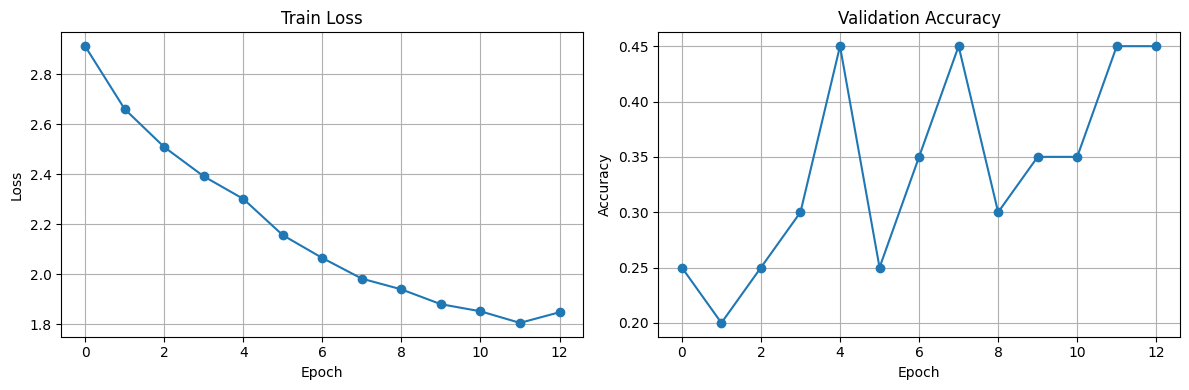

In [15]:

# ─────────────────────────────────────────
# 6) Modelo ResNet50
# ─────────────────────────────────────────

model_ft = timm.create_model(
    "resnet50",
    pretrained=True,
    num_classes=num_classes
)

model_ft = model_ft.to(device)
in_features = model_ft.fc.in_features

model_ft.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, num_classes)
)


# ─────────────────────────────────────────
# 7) Congelar primeras capas
# evita sobreajuste
# ─────────────────────────────────────────

for name, param in model_ft.named_parameters():

    if (
        "layer4" not in name
        and "fc" not in name
    ):
        param.requires_grad = False


# ─────────────────────────────────────────
# 8) Optimizer
# LR distinto cabeza/backbone
# ─────────────────────────────────────────

optimizer = torch.optim.AdamW(

    [
        {
            "params": model_ft.fc.parameters(),
            "lr": 1e-3
        },

        {
            "params": [
                p for n, p in model_ft.named_parameters()
                if (
                    "layer4" in n
                    and p.requires_grad
                )
            ],
            "lr": 1e-5
        },
    ],

    weight_decay=0.01
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# ─────────────────────────────────────────
# 9) Loss
# ─────────────────────────────────────────

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)


# ─────────────────────────────────────────
# 10) Mixed precision
# ─────────────────────────────────────────

scaler = torch.cuda.amp.GradScaler(
    enabled=device.type == "cuda"
)


# ─────────────────────────────────────────
# 11) Early stopping
# ─────────────────────────────────────────

PATIENCE = 8

best_val_acc = 0.0
best_weights = None

patience_counter = 0


# ─────────────────────────────────────────
# 12) Entrenamiento
# ─────────────────────────────────────────

FINETUNE_EPOCHS = 30

history = {
    "train_loss": [],
    "val_acc": []
}

for epoch in range(1, FINETUNE_EPOCHS + 1):

    # ─────────────────────
    # TRAIN
    # ─────────────────────

    model_ft.train()

    running_loss = 0.0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(
            enabled=device.type == "cuda"
        ):

            logits = model_ft(x)

            loss = criterion(logits, y)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / n_train


    # ─────────────────────
    # VALIDACIÓN
    # ─────────────────────

    model_ft.eval()

    correct = 0
    total = 0

    with torch.inference_mode():

        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            logits = model_ft(x)

            preds = logits.argmax(dim=1)

            correct += (preds == y).sum().item()

            total += y.numel()

    val_acc = correct / total
    scheduler.step(val_acc)

    # ─────────────────────
    # GUARDAR HISTORIAL
    # ─────────────────────

    history["train_loss"].append(train_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f}"
    )


    # ─────────────────────
    # EARLY STOPPING
    # ─────────────────────

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_weights = copy.deepcopy(
            model_ft.state_dict()
        )

        patience_counter = 0

        print("  -> Mejor modelo guardado")

    else:

        patience_counter += 1

        print(
            f"  -> Sin mejora "
            f"({patience_counter}/{PATIENCE})"
        )

        if patience_counter >= PATIENCE:

            print("\nEarly stopping activado")
            break


# ─────────────────────────────────────────
# 13) Restaurar mejor modelo
# ─────────────────────────────────────────

model_ft.load_state_dict(best_weights)

print(f"\nMejor val_acc: {best_val_acc:.4f}")


# ─────────────────────────────────────────
# 14) Guardar modelo
# ─────────────────────────────────────────

Path("models").mkdir(exist_ok=True)

torch.save(
    model_ft.state_dict(),
    "models/resnet50_finetuned.pth"
)

print("\nModelo guardado")


# ─────────────────────────────────────────
# 15) Curvas entrenamiento
# ─────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

# loss
ax1.plot(
    history["train_loss"],
    marker="o"
)

ax1.set_title("Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

# accuracy
ax2.plot(
    history["val_acc"],
    marker="o"
)

ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────
# Evaluación final en Test Set
# ─────────────────────────────────────────

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
# ─────────────────────────────────────────
# Reconstruir arquitectura
# ─────────────────────────────────────────
num_classes = train_df["label"].nunique()
model_clf = timm.create_model(
    "resnet50",
    pretrained=False,
    num_classes=num_classes
)

# misma cabeza usada en entrenamiento
in_features = model_clf.fc.in_features

model_clf.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, num_classes)
)

model_clf = model_clf.to(device)

# ─────────────────────────────────────────
# Cargar pesos
# ─────────────────────────────────────────

state_dict = torch.load(
    "models/resnet50_finetuned.pth",
    map_location=device
)

model_clf.load_state_dict(state_dict)

model_clf.eval()

all_preds  = []
all_labels = []

with torch.inference_mode():
    for x, y in test_loader:
        x      = x.to(device)
        logits = model_clf(x)
        preds  = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(y)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Usar solo las clases presentes en test
labels_present = sorted(np.unique(all_labels).tolist())
id_to_name     = df.drop_duplicates("label").set_index("label")["name"].to_dict()
class_names    = [id_to_name[i] for i in labels_present]

acc    = accuracy_score(all_labels, all_preds)
f1_mac = f1_score(all_labels, all_preds, average="macro")
f1_wei = f1_score(all_labels, all_preds, average="weighted")

print("=" * 50)
print("  EVALUACIÓN FINAL — TEST SET")
print("=" * 50)
print(f"  Accuracy          : {acc:.4f} ({acc*100:.2f}%)")
print(f"  F1 Macro          : {f1_mac:.4f}")
print(f"  F1 Weighted       : {f1_wei:.4f}")
print(f"  Imágenes evaluadas: {len(all_labels)}")
print("=" * 50)

print("\nReporte por clase:\n")
print(classification_report(all_labels, all_preds, labels=labels_present, target_names=class_names))

  EVALUACIÓN FINAL — TEST SET
  Accuracy          : 0.2308 (23.08%)
  F1 Macro          : 0.1639
  F1 Weighted       : 0.1681
  Imágenes evaluadas: 39

Reporte por clase:

                    precision    recall  f1-score   support

      Alfredo Sanz       0.00      0.00      0.00         1
        Alma Lopez       0.25      0.50      0.33         2
      Ariel Sharon       0.00      0.00      0.00         2
      Colin Powell       1.00      0.50      0.67         2
   Donald Rumsfeld       0.00      0.00      0.00         2
     George W Bush       0.00      0.00      0.00         2
Georgina Contrucci       1.00      0.50      0.67         2
 Gerhard Schroeder       0.25      0.50      0.33         2
       Hugo Chavez       0.00      0.00      0.00         2
    Jacques Chirac       0.00      0.00      0.00         2
     Jean Chretien       0.00      0.00      0.00         2
     John Ashcroft       0.14      0.50      0.22         2
 Junichiro Koizumi       0.25      0.50      0.